<a href="https://colab.research.google.com/github/vtimkov299-alt/33105387_Database_and_Analytics_Coursework/blob/main/02_R_Analytics_and_SQL_in_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%load_ext rpy2.ipython

In [3]:
import os
print(os.listdir())

['.config', 'drive', 'sample_data']


In [4]:
%%R
library(dplyr)

base_path <- "/content/drive/MyDrive/northstar_dataset/"

orders <- read.csv(paste0(base_path, "orders.csv"))
deliveries <- read.csv(paste0(base_path, "deliveries.csv"))
complaints <- read.csv(paste0(base_path, "complaints.csv"))
drivers <- read.csv(paste0(base_path, "drivers.csv"))
vehicles <- read.csv(paste0(base_path, "vehicles.csv"))
incidents <- read.csv(paste0(base_path, "incidents.csv"))


Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



In [5]:
# =========================
# SQL IN R
# =========================

In [6]:
%%R
install.packages("sqldf", repos = "https://cloud.r-project.org")
library(sqldf)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’

trying URL 'https://cloud.r-project.org/src/contrib/gsubfn_0.7.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/proto_1.0.0.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/RSQLite_3.52.0.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/chron_2.3-62.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/sqldf_0.4-12.tar.gz'

The downloaded source packages are in
	‘/tmp/RtmpDAS1cu/downloaded_packages’
Loading required package: gsubfn
Loading required package: proto
Loading required package: RSQLite
In addition: Warning message:
no DISPLAY variable so Tk is not available 


In [7]:
%%R
sqldf("
  SELECT
    LOWER(o.pickup_zone) AS pickup_zone,
    COUNT(*) AS total_deliveries
  FROM deliveries d
  JOIN orders o
    ON d.order_id = o.order_id
  GROUP BY LOWER(o.pickup_zone)
  ORDER BY total_deliveries DESC
")

  pickup_zone total_deliveries
1        east              156
2       south              139
3       north              135
4   riverside              119
5        west              114
6     airport              113
7     central              110
8         ctr               64


In [8]:
%%R
sqldf("
  SELECT
    LOWER(o.pickup_zone) AS pickup_zone,
    AVG(CASE WHEN LOWER(d.delivery_status) = 'failed' THEN 1.0 ELSE 0.0 END) AS failure_rate
  FROM deliveries d
  JOIN orders o
    ON d.order_id = o.order_id
  GROUP BY LOWER(o.pickup_zone)
  ORDER BY failure_rate DESC
")

  pickup_zone failure_rate
1     central    0.2000000
2         ctr    0.1718750
3       north    0.1629630
4   riverside    0.1512605
5        west    0.1228070
6        east    0.1217949
7     airport    0.1061947
8       south    0.1007194


In [9]:
# =========================
# R ANALYTICS
# =========================

In [10]:
%%R
deliveries_orders <- merge(deliveries, orders, by = "order_id")

deliveries_orders$pickup_zone <- tolower(deliveries_orders$pickup_zone)
deliveries_orders$delivery_status <- tolower(deliveries_orders$delivery_status)
complaints$severity <- tolower(complaints$severity)
deliveries$delivery_status <- tolower(deliveries$delivery_status)

In [11]:
%%R
deliveries_orders %>%
  group_by(pickup_zone) %>%
  summarise(total_deliveries = n()) %>%
  arrange(desc(total_deliveries))

# A tibble: 8 × 2
  pickup_zone total_deliveries
  <chr>                  <int>
1 east                     156
2 south                    139
3 north                    135
4 riverside                119
5 west                     114
6 airport                  113
7 central                  110
8 ctr                       64


In [12]:
%%R
deliveries_orders %>%
  group_by(pickup_zone) %>%
  summarise(
    failure_rate = mean(delivery_status == "failed")
  ) %>%
  arrange(desc(failure_rate))

# A tibble: 8 × 2
  pickup_zone failure_rate
  <chr>              <dbl>
1 central            0.2  
2 ctr                0.172
3 north              0.163
4 riverside          0.151
5 west               0.123
6 east               0.122
7 airport            0.106
8 south              0.101


In [13]:
%%R
deliveries %>%
  summarise(
    avg_rating = mean(customer_rating_post_delivery, na.rm = TRUE)
  )

  avg_rating
1   3.864679


In [14]:
%%R
complaints %>%
  group_by(complaint_type) %>%
  summarise(count = n()) %>%
  arrange(desc(count))

# A tibble: 7 × 2
  complaint_type    count
  <chr>             <int>
1 Delay               101
2 MissedPickup         64
3 AppIssue             53
4 DriverBehaviour      51
5 SupportExperience    20
6 Billing              16
7 Damage               15


In [15]:
%%R
complaints %>%
  filter(severity == "high") %>%
  summarise(total_high = n())

  total_high
1         77


In [16]:
%%R
complaints %>%
  group_by(complaint_type) %>%
  summarise(
    avg_compensation = mean(compensation_amount, na.rm = TRUE)
  ) %>%
  arrange(desc(avg_compensation))

# A tibble: 7 × 2
  complaint_type    avg_compensation
  <chr>                        <dbl>
1 Damage                        24.0
2 Billing                       23.9
3 MissedPickup                  22.6
4 DriverBehaviour               21.2
5 AppIssue                      19.6
6 Delay                         18.1
7 SupportExperience             17.1


In [17]:
%%R
deliveries %>%
  group_by(delivery_status) %>%
  summarise(count = n()) %>%
  arrange(desc(count))

# A tibble: 3 × 2
  delivery_status count
  <chr>           <int>
1 ontime            616
2 delayed           202
3 failed            132


In [18]:
%%R
orders %>%
  group_by(service_type) %>%
  summarise(
    avg_promised_window = mean(promised_window_hours, na.rm = TRUE)
  ) %>%
  arrange(desc(avg_promised_window))

# A tibble: 5 × 2
  service_type avg_promised_window
  <chr>                      <dbl>
1 Parcel                      8.30
2 Retail                      7.88
3 Medical                     7.42
4 Passenger                   7.20
5 Business                    6.93


In [19]:
%%R
install.packages("ggplot2", repos = "https://cloud.r-project.org")
library(ggplot2)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cloud.r-project.org/src/contrib/ggplot2_4.0.3.tar.gz'
Content type 'application/x-gzip' length 6327703 bytes (6.0 MB)
downloaded 6.0 MB


The downloaded source packages are in
	‘/tmp/RtmpDAS1cu/downloaded_packages’


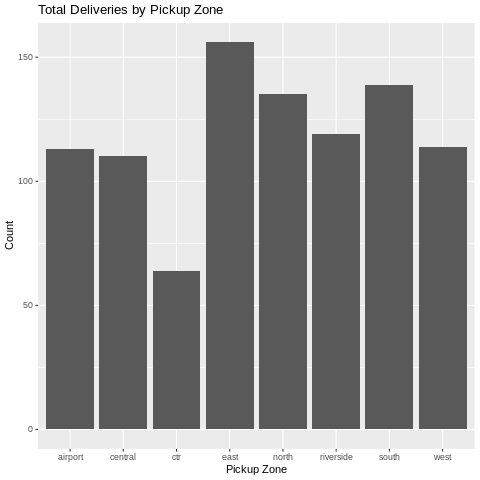

In [20]:
%%R
ggplot(deliveries_orders, aes(x = pickup_zone)) +
  geom_bar() +
  ggtitle("Total Deliveries by Pickup Zone") +
  xlab("Pickup Zone") +
  ylab("Count")

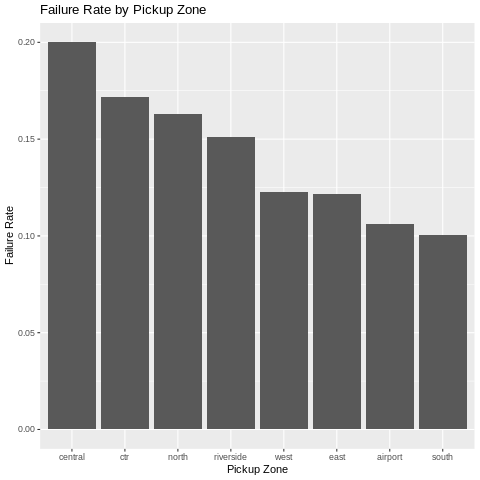

In [21]:
%%R
failure_summary <- deliveries_orders %>%
  group_by(pickup_zone) %>%
  summarise(failure_rate = mean(delivery_status == "failed"))

ggplot(failure_summary, aes(x = reorder(pickup_zone, -failure_rate), y = failure_rate)) +
  geom_col() +
  ggtitle("Failure Rate by Pickup Zone") +
  xlab("Pickup Zone") +
  ylab("Failure Rate")

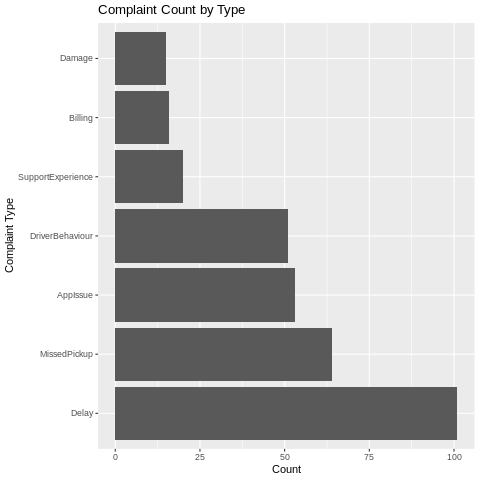

In [22]:
%%R
complaint_summary <- complaints %>%
  group_by(complaint_type) %>%
  summarise(count = n()) %>%
  arrange(desc(count))

ggplot(complaint_summary, aes(x = reorder(complaint_type, -count), y = count)) +
  geom_col() +
  ggtitle("Complaint Count by Type") +
  xlab("Complaint Type") +
  ylab("Count") +
  coord_flip()

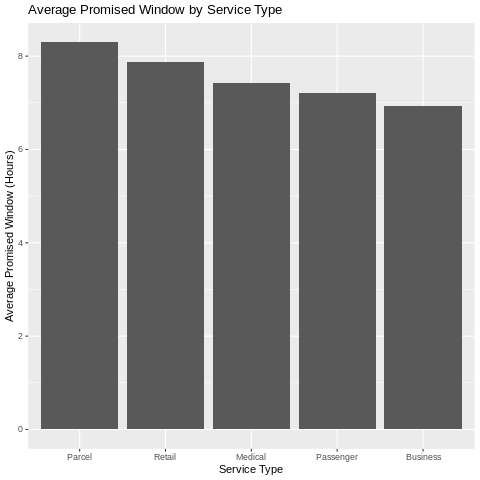

In [23]:
%%R
service_summary <- orders %>%
  group_by(service_type) %>%
  summarise(avg_promised_window = mean(promised_window_hours, na.rm = TRUE))

ggplot(service_summary, aes(x = reorder(service_type, -avg_promised_window), y = avg_promised_window)) +
  geom_col() +
  ggtitle("Average Promised Window by Service Type") +
  xlab("Service Type") +
  ylab("Average Promised Window (Hours)")

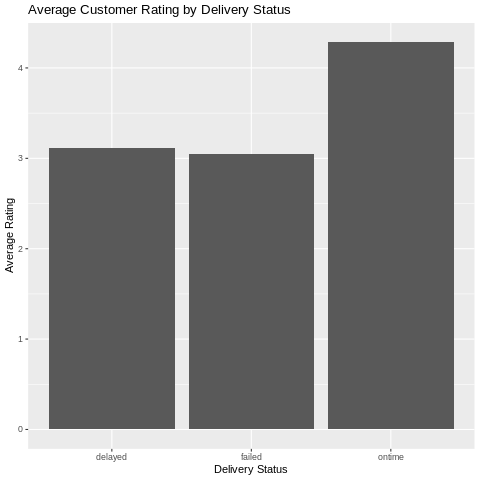

In [24]:
%%R
rating_by_status <- deliveries %>%
  filter(!is.na(customer_rating_post_delivery)) %>%
  group_by(delivery_status) %>%
  summarise(avg_rating = mean(customer_rating_post_delivery, na.rm = TRUE))

ggplot(rating_by_status, aes(x = delivery_status, y = avg_rating)) +
  geom_col() +
  ggtitle("Average Customer Rating by Delivery Status") +
  xlab("Delivery Status") +
  ylab("Average Rating")